# FTL099 - Inteligência Artificial Aplicada  
Aluno: Nycksandro Lima dos Santos  
Matrícula: 22351228  

# Trabalho 05 - Classificadores Lineares  

A base de dados ORL (Laboratório de Pesquisa da Olivetti) contém 10 imagens diferentes de cada 40 indivíduos, totalizando 400 imagens de tamanho 92x112 pixels. Para alguns indivíduos, as imagens foram capturadas em diferentes épocas, variando em iluminação, expressões faciais (olhos abertos e fechados, sorrindo ou não) e com detalhes na face
(com ou sem óculos). Todas as imagens foram capturadas com um fundo negro homogêneo. Esta base pode ser encontrada na pasta da disciplina e no site:
https://www.kaggle.com/datasets/kasikrit/att-database-of-faces. Pretende-se nesse trabalho fazer o reconhecimento das faces dos indivíduos dessas bases de dados com uma rede convolutiva.

1. Resolver o problema com a arquitetura 1:
CONV-BATCH-RELU-POOLING-FULLCONNECT-SOFTMAX-CLASSIFIER
2. Resolver o problema com a arquitetura 2: CONV-BATCH-RELU-POOLING-CONV-BATCH-RELU-POOLING- CONV-
BATCH-RELU POOLING–FULLCONNECT-SOFTMAX CLASSIFIER
3. Mostrar gráficos contendo a variação da acurácia ao longo do treinamento para as duas redes.
4. Utilize 70% dos dados para treinamento e 30% para teste.
5. É desejável que o melhor resultado seja uma acurácia acima de 95%. Caso não
consiga atingir valores de acurácia acima de 95% fique à vontade para propor outras arquiteturas.
6. Nos resultados pede-se mostrar, para cada rede: valor da acurácia e tabela de
confusão.

# Importando Bibiliotecas

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np
import kagglehub
import seaborn as sns
from PIL import Image
import os

# Baixando o Dataset

In [4]:
caminho_dataset = kagglehub.dataset_download("kasikrit/att-database-of-faces")

print("O Dataset AT&T Database of Faces se encontra em:", caminho_dataset)

100%|██████████| 3.61M/3.61M [00:01<00:00, 2.30MB/s]

Extracting files...


O Dataset AT&T Database of Faces se encontra em: /root/.cache/kagglehub/datasets/kasikrit/att-database-of-faces/versions/2


# Convertendo o Dataset
Como as imagens do dataset estão no formato "PGM", será necessário converter-las em um formato que o Keras consiga utilizar.

In [5]:
# Nessa célula é criado uma cópia do dataset no caminho "destino" onde todas as imagens estarão no formato "PNG"

origem = caminho_dataset
destino = caminho_dataset.replace('input', 'convertido')

os.makedirs(destino, exist_ok=True)

for pasta in os.listdir(origem):
    pasta_origem = os.path.join(origem, pasta)

    if not os.path.isdir(pasta_origem):
        continue

    pasta_destino = os.path.join(destino, pasta)
    os.makedirs(pasta_destino, exist_ok=True)

    for arquivo in os.listdir(pasta_origem):
        if arquivo.endswith(".pgm"):
            img = Image.open(os.path.join(pasta_origem, arquivo))

            novo_nome = arquivo.replace(".pgm", ".png")
            img.save(os.path.join(pasta_destino, novo_nome))

caminho_dataset = destino

# Divisão das partições

A proporção de divisão dos dados é:

* 70% (280 imagens) para a partição de Treino
* 30% (120 imagens) para partição de Teste

In [29]:
NUM_CLASSES = 40
BATCH_SIZE = 16
RESCALE= 1./255
data_dir = caminho_dataset

datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=RESCALE,
    validation_split=0.3
)

train_ds = datagen.flow_from_directory(
    data_dir,
    target_size=(112, 92),
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=BATCH_SIZE,
    subset="training",
    seed=123
)

valid_ds = datagen.flow_from_directory(
    data_dir,
    target_size=(112, 92),
    shuffle=False,
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=BATCH_SIZE,
    subset="validation",
    seed=123
)

Found 280 images belonging to 40 classes.
Found 120 images belonging to 40 classes.


In [7]:
x_batch, y_batch = next(train_ds)

17.0


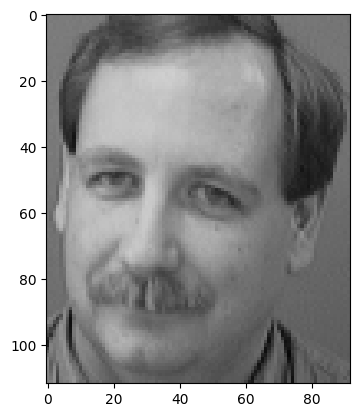

In [8]:
# Exemplo de imagem
print(y_batch[0])
image = x_batch[0]
plt.imshow(image, vmin=0, vmax=1, cmap=plt.cm.gray)
plt.show()

# Construção dos modelos

## Modelo 1

In [9]:
#Modelo 1: CONV-BATCH-RELU-POOLING-FULLCONNECT-SOFTMAX-CLASSIFIER

modelo_1 = Sequential([
    layers.Input(shape=(112, 92, 1)),

    layers.Conv2D(32, (3,3), padding='same'), # CONV
    layers.BatchNormalization(), # BATCH
    layers.ReLU(), # RELU
    layers.MaxPooling2D((2,2)), # POOLING

    # FULLCONECT
    layers.Flatten(),

    layers.Dense(256),
    layers.ReLU(),
    layers.Dropout(0.5),

    layers.Dense(40, activation='softmax') # SOFTMAX
])

modelo_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 112, 92, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 92, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 112, 92, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 56, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    21,102,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,113,576 (80.54 MB)

 Trainable params: 21,113,512 (80.54 MB)

 Non-trainable params: 64 (256.00 B)

## Modelo 2

In [12]:
# CONV-BATCH-RELU-POOLING-CONV-BATCH-RELU-POOLING- CONV-BATCH-RELU POOLING–FULLCONNECT-SOFTMAX CLASSIFIER
modelo_2 = Sequential([
    layers.Input(shape=(112, 92, 1)),

    # Bloco 1
    layers.Conv2D(32, (3,3), padding='same'), # CONV
    layers.BatchNormalization(), # BATCH
    layers.ReLU(), # RELU
    layers.MaxPooling2D((2,2)), # POOLING

    # Bloco 2
    layers.Conv2D(64, (3,3), padding='same'), # CONV
    layers.BatchNormalization(), # BATCH
    layers.ReLU(), # RELU
    layers.MaxPooling2D((2,2)), # POOLING

    # Bloco 3
    layers.Conv2D(128, (3,3), padding='same'), # CONV
    layers.BatchNormalization(), # BATCH
    layers.ReLU(), # RELU
    layers.MaxPooling2D((2,2)), # POOLING

    # Fully Connected
    layers.Flatten(),
    layers.Dense(256),
    layers.ReLU(),
    layers.Dropout(0.5),

    # Classificador
    layers.Dense(NUM_CLASSES, activation='softmax') # SOFTMAX
])

modelo_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 112, 92, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 92, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 112, 92, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 56, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 28, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 19712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     5,046,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,150,376 (19.65 MB)

 Trainable params: 5,149,928 (19.65 MB)

 Non-trainable params: 448 (1.75 KB)

## Configurando o treinamento

In [10]:
# Configurando a callback para restourar os melhores pesos e ter paciência = 30 e 50
callback_modelo1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True)

callback_modelo2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True)

In [13]:
# Configurando os compile de ambos os modelos
modelo_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy', # Para ter de 0-39 classes (40 pessoas)
    metrics=['accuracy']
)

modelo_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy', # Para ter de 0-39 classes (40 pessoas)
    metrics=['accuracy']
)

# Treinamento dos modelos

## Modelo 1

In [14]:
# Treinamento do modelo 1
historico_1 = modelo_1.fit(train_ds,
                    validation_data=valid_ds,
                    epochs=75,
                    callbacks=callback_modelo1)

Epoch 1/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 202ms/step - accuracy: 0.0821 - loss: 5.3485 - val_accuracy: 0.0333 - val_loss: 3.6283
Epoch 2/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.1786 - loss: 3.0470 - val_accuracy: 0.0750 - val_loss: 3.6217
Epoch 3/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2750 - loss: 2.5243 - val_accuracy: 0.0917 - val_loss: 3.5465
Epoch 4/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4000 - loss: 2.1428 - val_accuracy: 0.1750 - val_loss: 3.5038
Epoch 5/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4679 - loss: 1.8981 - val_accuracy: 0.2750 - val_loss: 3.4674
Epoch 6/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5214 - loss: 1.6007 - val_accuracy: 0.3250 - val_loss: 3.4000
Epoch 7/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5643 - loss: 1.4714 - val_accuracy: 0.5083 - val_loss: 3.3152
Epoch 8/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6286 - loss: 1.3114 - val_accuracy: 0.6917 - 

## Modelo 2

In [17]:
# Treinamento do modelo 2
historico_2 = modelo_2.fit(train_ds,
                    validation_data=valid_ds,
                    epochs=75,
                    callbacks=callback_modelo2)

Epoch 1/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 332ms/step - accuracy: 0.0679 - loss: 4.3530 - val_accuracy: 0.0250 - val_loss: 3.6847
Epoch 2/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2714 - loss: 2.6897 - val_accuracy: 0.0250 - val_loss: 3.6840
Epoch 3/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4393 - loss: 2.0184 - val_accuracy: 0.0250 - val_loss: 3.6910
Epoch 4/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5464 - loss: 1.6823 - val_accuracy: 0.0250 - val_loss: 3.7100
Epoch 5/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6750 - loss: 1.1982 - val_accuracy: 0.0250 - val_loss: 3.7218
Epoch 6/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7464 - loss: 0.9655 - val_accuracy: 0.0250 - val_loss: 3.7430
Epoch 7/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7786 - loss: 0.7779 - val_accuracy: 0.0250 - val_loss: 3.7600
Epoch 8/75
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8750 - loss: 0.5599 - val_accuracy: 0.0250 -

# Variação da Acurácia ao longo do Treinamento

## Modelo 1

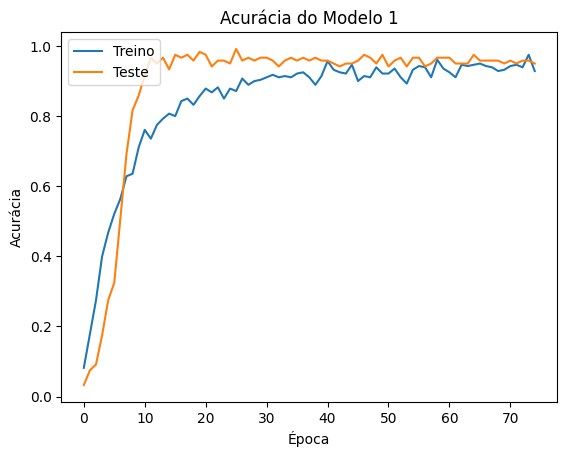

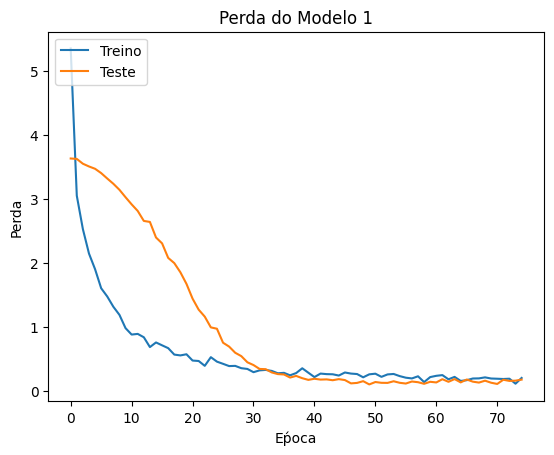

In [18]:
# Histórico da acurácia do modelo 1 ao longo do treinamento
plt.plot(historico_1.history['accuracy'])
plt.plot(historico_1.history['val_accuracy'])
plt.title('Acurácia do Modelo 1')
plt.ylabel('Acurácia')
plt.xlabel('Época')
plt.legend(['Treino', 'Teste'], loc='upper left')
plt.show()

# Histórico da perda do modelo 1 ao longo do treinamento
plt.plot(historico_1.history['loss'])
plt.plot(historico_1.history['val_loss'])
plt.title('Perda do Modelo 1')
plt.ylabel('Perda')
plt.xlabel('Eṕoca')
plt.legend(['Treino', 'Teste'], loc='upper left')
plt.show()

## Modelo 2

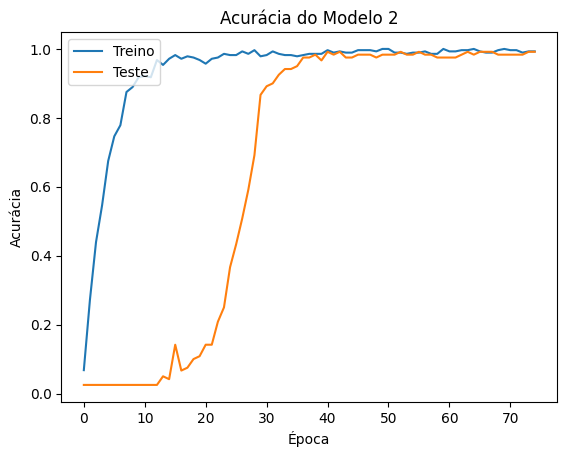

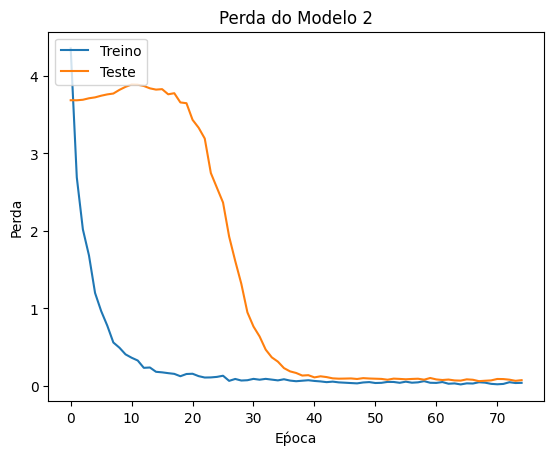

In [19]:
# Histórico da acurácia do modelo 2 ao longo do treinamento
plt.plot(historico_2.history['accuracy'])
plt.plot(historico_2.history['val_accuracy'])
plt.title('Acurácia do Modelo 2')
plt.ylabel('Acurácia')
plt.xlabel('Época')
plt.legend(['Treino', 'Teste'], loc='upper left')
plt.show()

# Histórico da perda do modelo 2 ao longo do treinamento
plt.plot(historico_2.history['loss'])
plt.plot(historico_2.history['val_loss'])
plt.title('Perda do Modelo 2')
plt.ylabel('Perda')
plt.xlabel('Eṕoca')
plt.legend(['Treino', 'Teste'], loc='upper left')
plt.show()

# Avaliação dos modelos

In [20]:
scores_1 = modelo_1.evaluate(valid_ds)
scores_2 = modelo_2.evaluate(valid_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9750 - loss: 0.0975
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9917 - loss: 0.0613


In [21]:
Y_predito_1 = modelo_1.predict(valid_ds)
Y_predito_1

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


array([[5.82205712e-06, 3.22013989e-06, 1.13573566e-03, ...,
        6.75719946e-07, 6.69410110e-06, 8.66749588e-08],
       [1.18654380e-05, 7.69743878e-08, 9.99765456e-01, ...,
        5.51891162e-07, 1.12244079e-05, 1.33539313e-09],
       [8.11302802e-04, 2.30874226e-04, 9.11261886e-04, ...,
        2.75649782e-05, 1.91897340e-02, 1.78245245e-03],
       ...,
       [4.29187698e-04, 2.10304528e-01, 1.40052324e-03, ...,
        6.59022908e-06, 5.90556562e-01, 2.10979162e-03],
       [1.60169884e-06, 2.56690953e-04, 1.20052755e-05, ...,
        3.43842572e-07, 5.06083188e-06, 6.35557342e-04],
       [2.21688470e-06, 5.99713701e-08, 6.82521431e-07, ...,
        2.01208028e-03, 2.26859882e-07, 5.44901049e-08]], dtype=float32)

In [22]:
Y_predito_2 = modelo_2.predict(valid_ds)
Y_predito_2

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step


array([[2.1921019e-07, 2.8147065e-07, 2.5922144e-08, ..., 1.4493911e-07,
        3.1110354e-09, 5.7546062e-10],
       [5.4040243e-07, 4.6083852e-09, 6.9514321e-08, ..., 4.1983299e-08,
        1.0826246e-07, 6.3481613e-04],
       [1.3879408e-06, 1.7188098e-06, 1.9641764e-06, ..., 1.3302159e-05,
        6.1001519e-06, 3.0886365e-06],
       ...,
       [2.5275935e-05, 5.8255523e-06, 5.9168087e-05, ..., 7.3419587e-06,
        1.5822728e-06, 1.8181428e-06],
       [1.4317944e-05, 1.0147023e-08, 2.8379421e-09, ..., 4.3811338e-10,
        6.3122597e-11, 7.7715495e-10],
       [1.6467601e-04, 2.1643024e-05, 5.4746641e-05, ..., 2.6151049e-05,
        4.8928514e-06, 6.6411565e-07]], dtype=float32)

# Matriz de confusão

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


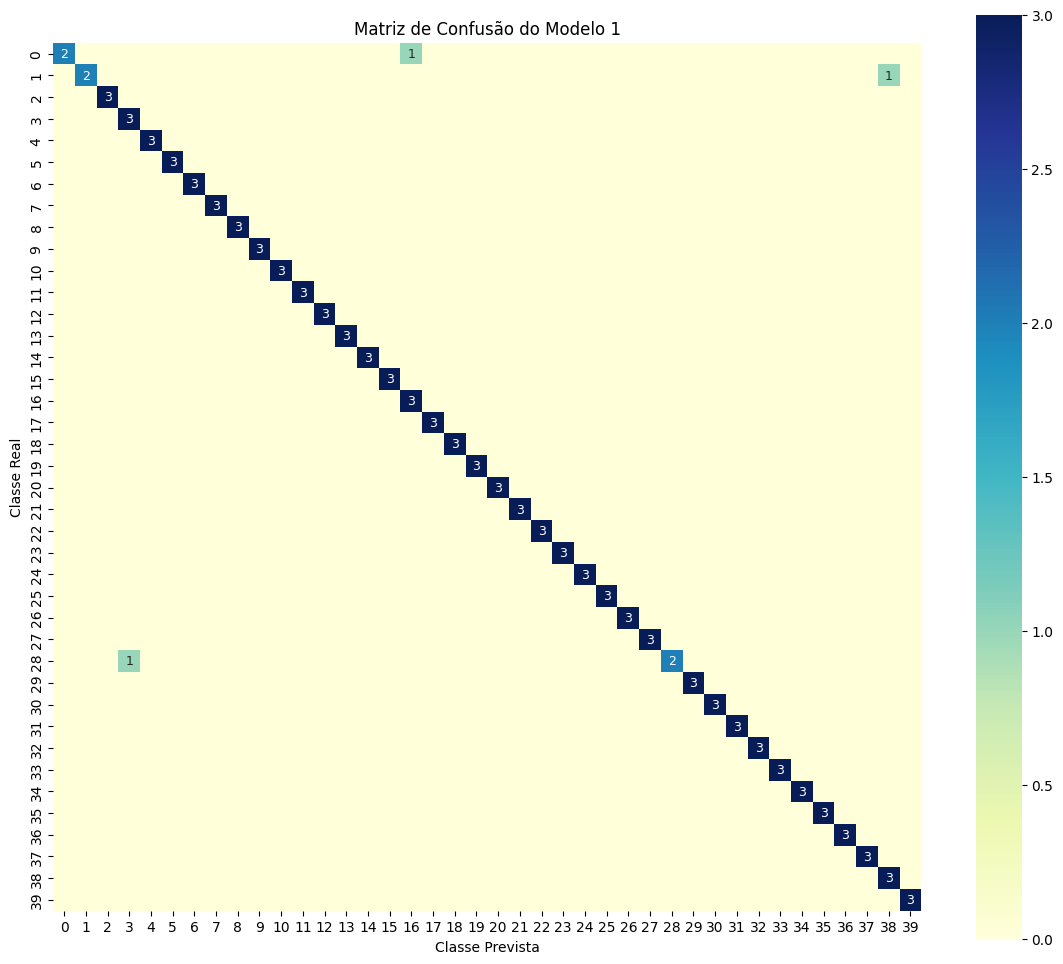

In [30]:
y_pred_prob = modelo_1.predict(valid_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = valid_ds.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))

cm_labels = np.where(cm == 0, "", cm.astype(str))

sns.heatmap(
    cm,
    annot=cm_labels,
    fmt='',
    cmap='YlGnBu',
    cbar=True,
    square=True,
    annot_kws={"size": 9})

plt.title('Matriz de Confusão do Modelo 1')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')

plt.show()

## Modelo 1

## Modelo 2

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


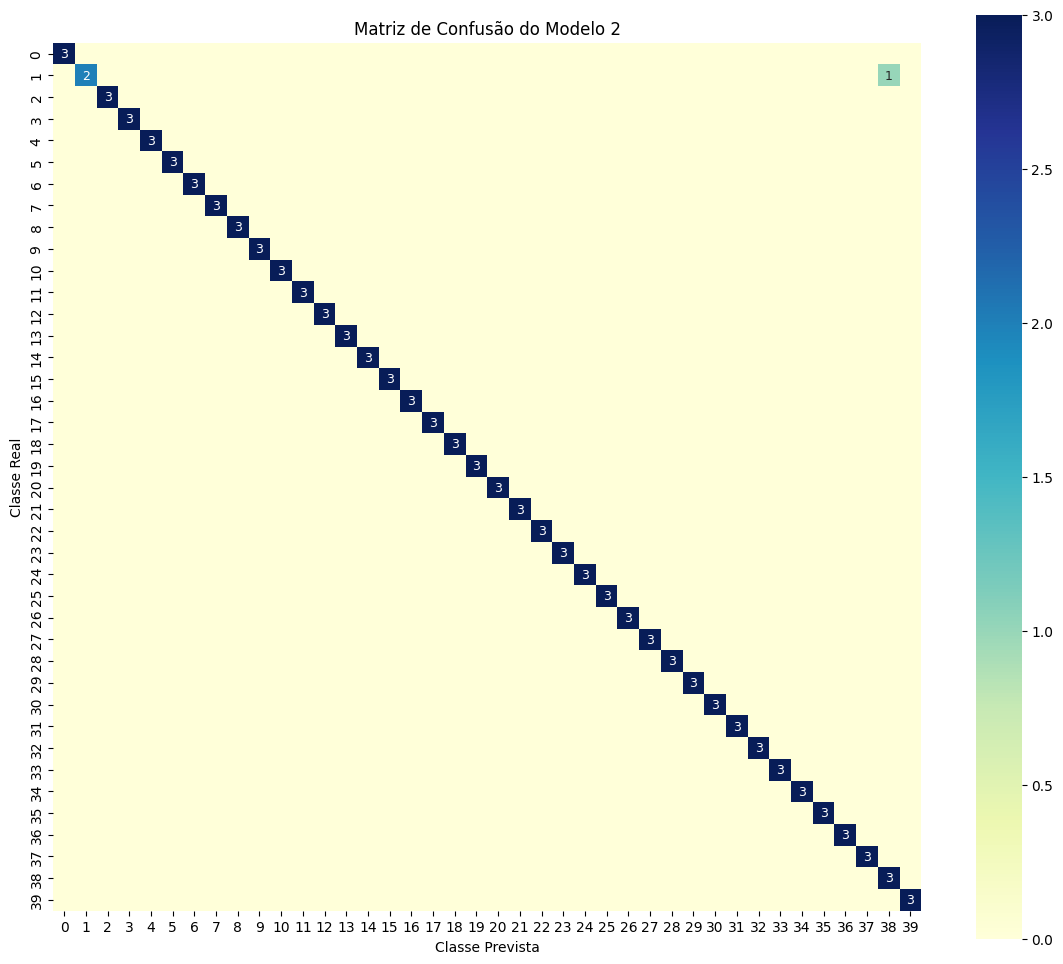

In [31]:
y_pred_prob = modelo_2.predict(valid_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = valid_ds.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))

cm_labels = np.where(cm == 0, "", cm.astype(str))

sns.heatmap(
    cm,
    annot=cm_labels,
    fmt='',
    cmap='YlGnBu',
    cbar=True,
    square=True,
    annot_kws={"size": 9})

plt.title('Matriz de Confusão do Modelo 2')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')

plt.show()

# Pesos finais

## Modelo 1

In [25]:
for layer in modelo_1.layers:
    print(f"\nCamada: {layer.name}")

    pesos = layer.get_weights()

    if len(pesos) == 0:
        print("Sem pesos treináveis")
        continue

    for i, w in enumerate(pesos):
        print(f"Peso {i}: shape = {w.shape}")
        print(w)


Camada: conv2d
Peso 0: shape = (3, 3, 1, 32)
[[[[ 3.32212597e-02 -2.33627893e-02 -3.88836078e-02 -2.27550752e-02
    -1.38075992e-01  1.07964173e-01  1.07917607e-01  2.98603680e-02
    -1.58605259e-02 -2.87482515e-02 -1.33817615e-02 -1.26023278e-01
    -2.59509683e-02 -1.54628735e-02  5.04471995e-02 -5.35303950e-02
     7.16440901e-02 -1.65137798e-02  2.19411701e-02 -1.34133458e-01
    -6.81485087e-02 -4.39760983e-02  7.92134851e-02 -9.77250040e-02
    -1.51656806e-01 -4.42332737e-02  5.50962240e-02 -9.12695080e-02
    -1.73515920e-02 -8.38134959e-02 -1.31136626e-01  2.52273735e-02]]

  [[ 1.29783735e-01  7.88738951e-02  6.46757782e-02 -1.48181483e-01
     1.30395102e-03  6.09317459e-02 -7.23928213e-02  4.84135887e-03
     1.60044432e-02  2.73547396e-02  3.49933021e-02 -1.98406307e-03
     1.34423256e-01  1.18020944e-01 -1.53101310e-01  1.62995216e-02
    -1.25423282e-01 -3.26139294e-02  7.30207562e-02  1.28663704e-01
    -7.53348321e-02 -2.91242804e-02  1.30330697e-01 -8.82332679e-03

## Modelo 2

In [26]:
for layer in modelo_2.layers:
    print(f"\nCamada: {layer.name}")

    pesos = layer.get_weights()

    if len(pesos) == 0:
        print("Sem pesos treináveis")
        continue

    for i, w in enumerate(pesos):
        print(f"Peso {i}: shape = {w.shape}")
        print(w)


Camada: conv2d_1
Peso 0: shape = (3, 3, 1, 32)
[[[[ 0.06010316 -0.13135444  0.11696336 -0.0959342   0.12460065
     0.0184557   0.12190957  0.11817972  0.07811854 -0.01351483
    -0.08262239 -0.02255947 -0.11532971  0.09588934  0.11786509
    -0.07696608  0.05502665 -0.03509793  0.02068642 -0.03952926
    -0.11789903 -0.00701613 -0.05936894 -0.1352954   0.0365296
    -0.11173534 -0.00672087  0.1219603   0.02992699 -0.07064778
     0.1276997  -0.03919438]]

  [[ 0.06911888 -0.07230704  0.08670361 -0.08736942 -0.04556793
    -0.11922126 -0.09568875 -0.00898288 -0.0140341  -0.01570505
    -0.10651637  0.11796451 -0.11568427  0.12387021 -0.00407836
     0.1025468   0.07765783 -0.07857428  0.08896589  0.02757428
     0.06109179 -0.1189805  -0.02040751  0.12391252 -0.01664962
    -0.0132505   0.06584713  0.11802462 -0.13656199  0.09090347
    -0.04589408  0.04499711]]

  [[-0.01216788 -0.03529194 -0.03577841 -0.08089188  0.11330124
    -0.10550337 -0.13028926  0.07138732  0.10069696 -0.0944

# Pesos

## Modelo 1

In [27]:
for layer in modelo_1.layers:
    pesos = layer.get_weights()

    if pesos:
        print(layer.name)
        print("Média:", np.mean(pesos[0]))
        print("Desvio:", np.std(pesos[0]))

conv2d
Média: -0.0013730401
Desvio: 0.08162954
batch_normalization
Média: 1.0222538
Desvio: 0.009219161
dense
Média: -0.00029481231
Desvio: 0.005061216
dense_1
Média: -0.0014374268
Desvio: 0.0826868


## Modelo 2

In [28]:
for layer in modelo_2.layers:
    pesos = layer.get_weights()

    if pesos:
        print(layer.name)
        print("Média:", np.mean(pesos[0]))
        print("Desvio:", np.std(pesos[0]))

conv2d_1
Média: 0.00423278
Desvio: 0.08218151
batch_normalization_1
Média: 0.9998628
Desvio: 0.0026406208
conv2d_2
Média: 0.00022499038
Desvio: 0.04808542
batch_normalization_2
Média: 0.99998736
Desvio: 0.0030795939
conv2d_3
Média: 0.00060997816
Desvio: 0.034046993
batch_normalization_3
Média: 1.0119231
Desvio: 0.0027691396
dense_2
Média: -0.00030925855
Desvio: 0.010118383
dense_3
Média: -0.00051409076
Desvio: 0.0827757
